# UNIDAD 4: Distribuciones de Probabilidad Conjuntas y Bivariadas

**Duración:** 2.5 semanas (15 horas)

**Curso:** Probabilidad y Estadística Inferencial

**Institución:** Universidad de la Ciénega del Estado de Michoacán de Ocampo (UCEMICH)

**Profesor:** Luis José Yudico Anaya

**Carrera:** Ingeniería en Nanotecnología

**Nivel:** Tercer Semestre

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Multiagent-AI-Lab/Probability-Statistics-Agentic-AI-Core/blob/master/notebooks/UNIDAD_4_DISTRIBUCIONES_CONJUNTAS.ipynb)

In [1]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    repo_dir = "Probability-Statistics-Agentic-AI-Core"
    if not os.path.exists(repo_dir):
        !git clone -q https://github.com/Multiagent-AI-Lab/{repo_dir}.git
    os.chdir(repo_dir)
    %pip install -q -r requirements.txt
else:
    # Entorno local: ubicar la raiz del repo subiendo desde el cwd
    # (donde se lanzo Jupyter) y ponerla en sys.path para que
    # `from src.multiagent_core...` resuelva sin importar la carpeta actual.
    _raiz = next(
        (p for p in (Path.cwd(), *Path.cwd().parents)
         if (p / "src" / "multiagent_core").is_dir()),
        Path.cwd(),
    )
    if str(_raiz) not in sys.path:
        sys.path.insert(0, str(_raiz))


## Prerequisitos de esta unidad

- **PMF de Variables Aleatorias Discretas** (Unidad 3) — base directa para construir la PMF conjunta $P(X=x, Y=y)$ de dos o más variables.
- **Ciclo de Verificación Triple** (ver `GOVERNANCE.md`) — como en todas las unidades del curso, cada concepto con forma cerrada se verifica primero simbólicamente (SymPy) y luego se reproduce con las herramientas de producción (SciPy/statsmodels) antes de interpretarse.

## 1. Fundamentación Teórica: Distribuciones Conjuntas y Marginales

### 1.1 Concepto General
Cuando dos o más variables aleatorias se analizan simultáneamente, su comportamiento combinado se describe mediante una **distribución conjunta**: indica la probabilidad de que $X$ y $Y$ tomen determinados valores de forma simultánea.

Para variables **discretas**, la función de masa de probabilidad conjunta (PMF) se denota:
$$P_{X,Y}(x,y) = P(X = x,\ Y = y)$$

Para variables **continuas**, se utiliza la función de densidad de probabilidad conjunta (PDF) $f_{X,Y}(x,y)$.

### 1.2 Propiedades Básicas
1. **No-negatividad**: $P_{X,Y}(x,y)\ge0$, $f_{X,Y}(x,y)\ge0$.
2. **Normalización**:
   * Discretas: $\displaystyle\sum_x\sum_y P_{X,Y}(x,y)=1$
   * Continuas: $\displaystyle\int_{-\infty}^{\infty}\int_{-\infty}^{\infty} f_{X,Y}(x,y)\,dx\,dy = 1$

**Ejemplo intuitivo**: sea $X$ = número de bolas rojas extraídas y $Y$ = número de bolas azules extraídas de una urna. Cada par $(x,y)$ tiene una probabilidad $P_{X,Y}(x,y)$ que indica cuántas combinaciones producen ese resultado.

### 1.3 Distribuciones Marginales
La **distribución marginal** de una variable se obtiene a partir de la conjunta **eliminando** (sumando o integrando) la otra variable:
$$P_X(x)=\sum_y P_{X,Y}(x,y), \qquad P_Y(y)=\sum_x P_{X,Y}(x,y)$$
$$f_X(x)=\int_{-\infty}^{\infty} f_{X,Y}(x,y)\,dy,\qquad f_Y(y)=\int_{-\infty}^{\infty} f_{X,Y}(x,y)\,dx$$

**Ejemplo (discreto)**. Suponga la siguiente tabla de probabilidades conjuntas:

| X \ Y |   0  |   1  |  2  |
| :---: | :--: | :--: | :-: |
|   0   | 1/15 | 2/15 |  0  |
|   1   | 3/15 | 6/15 |  0  |
|   2   | 1/15 | 2/15 |  0  |

Marginal de $X$: $P_X(0)=3/15$, $P_X(1)=9/15$, $P_X(2)=3/15$.
Marginal de $Y$: $P_Y(0)=5/15$, $P_Y(1)=10/15$, $P_Y(2)=0$.

Las marginales resumen la información individual de cada variable sin considerar su relación conjunta y permiten calcular expectativas o probabilidades univariadas.

## 2. Independencia de Variables Aleatorias

### 2.1 Concepto y Criterio
Dos variables aleatorias $X$ y $Y$ son **independientes** si el conocimiento de una **no afecta** la distribución de la otra:
$$P_{X,Y}(x,y)=P_X(x)\,P_Y(y) \qquad \text{o, en el caso continuo,} \qquad f_{X,Y}(x,y)=f_X(x)\,f_Y(y)$$

### 2.2 Propiedades Clave
Si $X$ e $Y$ son independientes:
1. $E[XY]=E[X]\,E[Y]$
2. La covarianza es cero: $\mathrm{Cov}(X,Y)=E[(X-E[X])(Y-E[Y])]=0$

### 2.3 Ejemplo (Comprobación de Independencia, Discreto)
Con las marginales y conjunta de la tabla anterior: $P_X(1)=9/15$, $P_Y(1)=10/15$, $P_{X,Y}(1,1)=6/15$.

Si fueran independientes se debería cumplir $P_X(1)\cdot P_Y(1) = \frac{9}{15}\cdot\frac{10}{15} = \frac{90}{225} = 0.4$. Como $P_{X,Y}(1,1)=6/15=0.4$ también, la igualdad se sostiene para este par; verificándola en todos los pares $(x,y)$ se confirma si $X$ y $Y$ son independientes.

### 2.4 Ejemplo (Continuo)
Sea $f_{X,Y}(x,y)=2$ en el triángulo $0\le y\le x\le1$ y $0$ en otro caso.
* Marginal de $X$: $f_X(x)=\int_0^{x}2\,dy=2x$
* Marginal de $Y$: $f_Y(y)=\int_y^{1}2\,dx=2(1-y)$
* Producto: $f_X(x)f_Y(y)=4x(1-y)$, que **no coincide** con $f_{X,Y}(x,y)=2$; luego $X$ y $Y$ **no son independientes**.

### 2.5 Segundo Ejemplo (Continuo): Verificación de Independencia por Dos Métodos

El ejemplo anterior confirma dependencia porque el producto de marginales **no coincide** con la conjunta. El siguiente ejemplo muestra el caso contrario —confirmar independencia— y añade un segundo método de verificación: la PDF conjunta $f_{X,Y}(x,y)=2xe^{-(x+2y)}$ para $x,y\ge0$ modela el tiempo hasta el primer defecto detectable ($X$) y la profundidad de penetración de un recubrimiento protector ($Y$) en un proceso de pasivación de superficies.

**Paso 1 — Marginales**: separando la exponencial doble en factores integrables por separado:
$$f_X(x) = \int_0^\infty 2xe^{-(x+2y)}\,dy = 2xe^{-x}\int_0^\infty e^{-2y}\,dy = 2xe^{-x}\cdot\frac{1}{2} = xe^{-x}$$
$$f_Y(y) = \int_0^\infty 2xe^{-(x+2y)}\,dx = 2e^{-2y}\int_0^\infty xe^{-x}\,dx = 2e^{-2y}\cdot 1 = 2e^{-2y}$$
(la integral $\int_0^\infty xe^{-x}\,dx=1$ es la función Gamma $\Gamma(2)=1!=1$, así que $f_X(x)=xe^{-x}$ es una $\text{Gamma}(k=2,\theta=1)$, y $f_Y(y)=2e^{-2y}$ es una $\text{Exponencial}(\lambda=2)$).

**Paso 2 — Método 1: factorización directa**: $f_X(x)\cdot f_Y(y) = (xe^{-x})(2e^{-2y}) = 2xe^{-(x+2y)} = f_{X,Y}(x,y)$ ✓ — coincide exactamente, luego $X$ y $Y$ **son independientes**.

**Paso 3 — Método 2: la condicional no depende de la condicionante**: como verificación alternativa (útil cuando no es evidente cómo factorizar la conjunta a simple vista):
$$f_{X|Y}(x|y) = \frac{f_{X,Y}(x,y)}{f_Y(y)} = \frac{2xe^{-(x+2y)}}{2e^{-2y}} = xe^{-x}$$
El resultado **no contiene $y$** — la distribución condicional de $X$ es idéntica para cualquier valor fijo de $Y$, que es exactamente la definición de independencia ($f_{X|Y}(x|y)=f_X(x)$ para todo $y$).

In [2]:
import numpy as np
from scipy.integrate import dblquad

def f_xy(x, y):
    return 2 * x * np.exp(-(x + 2 * y))

## Verificacion 1: covarianza teoricamente nula si son independientes
E_X, _ = dblquad(lambda y, x: x * f_xy(x, y), 0, np.inf, 0, np.inf)
E_Y, _ = dblquad(lambda y, x: y * f_xy(x, y), 0, np.inf, 0, np.inf)
E_XY, _ = dblquad(lambda y, x: x * y * f_xy(x, y), 0, np.inf, 0, np.inf)
cov_xy = E_XY - E_X * E_Y

## Verificacion 2: simulacion Monte Carlo de la covarianza muestral
rng = np.random.default_rng(42)
X_sim = rng.gamma(shape=2, scale=1, size=200_000)   # marginal de X: Gamma(k=2, theta=1)
Y_sim = rng.exponential(scale=1 / 2, size=200_000)  # marginal de Y: Exponencial(lambda=2)
cov_sim = np.cov(X_sim, Y_sim)[0, 1]

print(f"E[X]={E_X:.4f}  E[Y]={E_Y:.4f}  E[XY]={E_XY:.4f}")
print(f"Cov(X,Y) analitica (deberia ser ~0):  {cov_xy:.6f}")
print(f"Cov(X,Y) simulada (variables independientes generadas por separado): {cov_sim:.6f}")


E[X]=2.0000  E[Y]=0.5000  E[XY]=1.0000
Cov(X,Y) analitica (deberia ser ~0):  0.000000
Cov(X,Y) simulada (variables independientes generadas por separado): 0.001227


**Verificación simbólica (SymPy) de la factorización**: en vez de solo verificar numéricamente que la covarianza es aproximadamente cero, se puede confirmar de forma exacta —vía integración simbólica— que las marginales obtenidas en el Paso 1 son las que efectivamente factorizan la conjunta:

In [3]:
import sympy as sp

x, y = sp.symbols('x y', positive=True)
f_xy_sym = 2 * x * sp.exp(-(x + 2 * y))

## Integracion simbolica de la conjunta para obtener cada marginal
f_x_sym = sp.simplify(sp.integrate(f_xy_sym, (y, 0, sp.oo)))
f_y_sym = sp.simplify(sp.integrate(f_xy_sym, (x, 0, sp.oo)))
print(f"f_X(x) = {f_x_sym}")  # debe dar x*exp(-x)
print(f"f_Y(y) = {f_y_sym}")  # debe dar 2*exp(-2*y)

## Confirmacion simbolica de independencia: f_X(x)*f_Y(y) == f_XY(x,y)
producto_marginales = sp.simplify(f_x_sym * f_y_sym)
diferencia = sp.simplify(producto_marginales - f_xy_sym)
print(f"f_X(x)*f_Y(y) = {producto_marginales}")
print(f"Coincide exactamente con f_X,Y(x,y): {diferencia == 0}")


f_X(x) = x*exp(-x)
f_Y(y) = 2*exp(-2*y)
f_X(x)*f_Y(y) = 2*x*exp(-x - 2*y)
Coincide exactamente con f_X,Y(x,y): True


Nótese que la simulación genera $X$ y $Y$ **por separado** (cada una de su propia marginal, sin acoplarlas) precisamente porque ya se demostró que son independientes — esa es la ventaja práctica de probar independencia analíticamente antes de simular: permite generar cada variable con su propio generador estándar (`rng.gamma`, `rng.exponential`) en vez de necesitar un método de simulación conjunta más complejo (como la Cholesky de la Sección 5.4, necesaria quando SÍ hay dependencia).

## 3. Distribuciones Condicionales (PMF/PDF) y Esperanza Condicional

### 3.1 PMF Condicional (Discreta)
Cuando se conoce el valor de una variable $X=x$, la incertidumbre sobre otra variable $Y$ cambia; la distribución resultante se denomina **distribución condicional**. Dadas dos variables aleatorias discretas $X$ e $Y$ con PMF conjunta $P_{X,Y}(x,y)$:
$$P_{Y|X}(y|x) = P(Y=y \mid X=x) = \frac{P_{X,Y}(x,y)}{P_X(x)}, \qquad P_X(x) > 0$$

**Propiedades**: (1) $\sum_y P_{Y|X}(y|x) = 1$ para $x$ fijo; (2) Regla de multiplicación: $P_{X,Y}(x,y) = P_X(x)\,P_{Y|X}(y|x)$.

**Ejemplo (urna con bolas rojas y azules)**: retomando $P_{X,Y}(1,0)=3/15$, $P_{X,Y}(1,1)=6/15$, $P_X(1)=9/15$:
$$P_{Y|X}(0|1) = \frac{3/15}{9/15} = \frac{1}{3}, \qquad P_{Y|X}(1|1) = \frac{6/15}{9/15} = \frac{2}{3}$$
Verificación: $\frac{1}{3}+\frac{2}{3}=1$. ✓

In [4]:
## Cálculo de PMF condicional discreta
import numpy as np
from fractions import Fraction

## PMF Conjunta P(x, y)
P_XY = {(0, 0): 0, (0, 1): Fraction(2, 15), (0, 2): Fraction(1, 15),
        (1, 0): Fraction(3, 15), (1, 1): Fraction(6, 15), (1, 2): 0,
        (2, 0): Fraction(3, 15), (2, 1): 0, (2, 2): 0}

## PMF Marginal de X
P_X_1 = Fraction(9, 15)
print(f"PMF Marginal P_X(1) = {P_X_1}")

## Calcular PMF Condicional P(Y | X=1)
print("\nPMF Condicional P(Y | X=1):")
for y in range(3):
    P_Y_cond_X = P_XY[(1, y)] / P_X_1
    print(f"P(Y={y} | X=1) = {P_Y_cond_X}")


PMF Marginal P_X(1) = 3/5

PMF Condicional P(Y | X=1):
P(Y=0 | X=1) = 1/3
P(Y=1 | X=1) = 2/3
P(Y=2 | X=1) = 0


### 3.2 PDF Condicional (Continua)
Dadas dos variables aleatorias continuas $X$ e $Y$ con PDF conjunta $f_{X,Y}(x,y)$:
$$f_{Y|X}(y|x) = \frac{f_{X,Y}(x,y)}{f_X(x)}, \qquad f_X(x) > 0$$

**Propiedades**: (1) $\int_{-\infty}^{\infty} f_{Y|X}(y|x)\,dy = 1$; (2) $f_{X,Y}(x,y) = f_{Y|X}(y|x)\,f_X(x)$; (3) si $X$ e $Y$ son independientes, $f_{Y|X}(y|x)=f_Y(y)$.

**Ejemplo**: sea $f_{X,Y}(x,y) = x+y$ para $0 \le x,y \le 1$. La marginal es $f_X(x) = \int_0^1(x+y)\,dy = x+\frac{1}{2}$, por lo que:
$$f_{Y|X}(y|x) = \frac{x+y}{x+\frac{1}{2}}$$
Con $x=0.5$: $f_{Y|X}(y|0.5) = 0.5+y$, y entonces:
$$P(Y<0.5 \mid X=0.5) = \int_0^{0.5} (0.5+y)\,dy = \boxed{0.375}$$

### 3.3 Esperanza Condicional
La **esperanza condicional** de $Y$ dado $X=x$ es el valor esperado de $Y$ respecto a su distribución condicional:
$$E[Y|X=x] = \sum_y y\,P_{Y|X}(y|x) \quad \text{(discreta)}, \qquad E[Y|X=x] = \int_{-\infty}^{\infty} y\,f_{Y|X}(y|x)\,dy \quad \text{(continua)}$$

**Propiedades**: (1) Linealidad: $E[aY+b|X]=aE[Y|X]+b$; (2) Ley de la Esperanza Total (iteración): $E[Y]=E[E[Y|X]]$; (3) si $X,Y$ independientes, $E[Y|X]=E[Y]$.

**Ejemplo discreto**: con $P_{Y|X}(0|1)=1/3$ y $P_{Y|X}(1|1)=2/3$:
$$E[Y|X=1]=0\cdot\frac{1}{3}+1\cdot\frac{2}{3}=\boxed{\frac{2}{3}}$$

**Ejemplo de aplicación de la Ley de la Esperanza Total**: si $E[Y|X=x]=2x+1$ y $E[X]=3$, entonces $E[Y]=E[2X+1]=2E[X]+1=\boxed{7}$.

In [5]:
## Esperanza condicional discreta
import numpy as np

y_vals = np.array([0, 1])
p_cond = np.array([1/3, 2/3])
E_Y_given_X1 = np.sum(y_vals * p_cond)
print(f"E[Y|X=1] = {E_Y_given_X1:.4f}")


E[Y|X=1] = 0.6667


### 3.4 Ley de la Esperanza Total: Ejemplo Continuo Completo

El ejemplo anterior ($E[Y|X=x]=2x+1$) muestra la mecánica algebraica de la Ley de la Esperanza Total, pero con una relación condicional ya lineal en $x$ dada de antemano. El siguiente ejemplo desarrolla el caso continuo desde una PDF real, con $X$ representando un parámetro de proceso: la temperatura de recocido de puntos cuánticos de grafeno (GQD) para celdas solares, $X\sim U(200,300)\ ^\circ\text{C}$, con eficiencia condicional $E[Y|X=x]=20+0.1x$ ($\%$).

Por la Ley de la Esperanza Total continua:
$$E[Y] = \int_{-\infty}^{\infty} E[Y|X=x]\,f_X(x)\,dx = \int_{200}^{300} (20+0.1x)\cdot\frac{1}{100}\,dx$$

$$E[Y] = \frac{1}{100}\left[20x + 0.05x^2\right]_{200}^{300} = \frac{1}{100}\big[(6000+4500)-(4000+2000)\big] = \frac{4500}{100} = \boxed{45.0\%}$$

In [6]:
from scipy import integrate

a, b = 200, 300  # soporte de X ~ U(200, 300)
alpha, beta = 20, 0.1  # E[Y|X=x] = alpha + beta*x


def esperanza_condicional(x):
    return alpha + beta * x


def pdf_uniforme(x):
    return 1 / (b - a) if a <= x <= b else 0


def integrando_let(x):
    return esperanza_condicional(x) * pdf_uniforme(x)


E_Y_quad, error = integrate.quad(integrando_let, a, b)
print(f"E[Y] via LET (quad): {E_Y_quad:.4f}%  (error estimado: {error:.2e})")


E[Y] via LET (quad): 45.0000%  (error estimado: 5.00e-13)


**Verificación simbólica (SymPy)**: la integral anterior se resolvió numéricamente vía `quad`; a continuación se repite el mismo cálculo mediante integración simbólica exacta, sustituyendo $E[Y|X=x]=20+0.1x$ y la densidad uniforme $f_X(x)=1/100$ ya establecidas en el texto:

In [7]:
import sympy as sp

x = sp.symbols('x', positive=True)
a_sym, b_sym = 200, 300
alpha_sym, beta_sym = 20, sp.Rational(1, 10)

e_y_dado_x = alpha_sym + beta_sym * x  # E[Y|X=x] = 20 + 0.1x, ya establecido arriba
f_x_uniforme = sp.Rational(1, b_sym - a_sym)  # densidad uniforme f_X(x) = 1/(300-200)

E_Y_sym = sp.integrate(e_y_dado_x * f_x_uniforme, (x, a_sym, b_sym))
E_Y_sym = sp.simplify(E_Y_sym)
print(f"E[Y] via integracion simbolica: {E_Y_sym} = {float(E_Y_sym)}%")  # debe dar 45.0


E[Y] via integracion simbolica: 45 = 45.0%


Este resultado es la base para el ejemplo mixto (discreto-continuo) de la Sección 3.5, que extiende la misma idea —promediar una esperanza condicional sobre la distribución de la variable condicionante— a un caso donde además se necesita descomponer la varianza total.

### 3.5 Ley de la Varianza Total: Ejemplo Mixto Discreto-Continuo

Cuando $E[Y|X=x]$ **depende de $x$** (como en 3.4), la varianza de $Y$ no es simplemente $E[\text{Var}(Y|X)]$: parte de la variabilidad de $Y$ proviene de que su propia media condicional cambia con $X$. La **Ley de la Varianza Total** descompone esto en dos términos:

$$\text{Var}(Y) = \underbrace{\mathbb{E}[\text{Var}(Y|X)]}_{\text{variabilidad "dentro" de cada valor de }X} + \underbrace{\text{Var}(\mathbb{E}[Y|X])}_{\text{variabilidad "entre" distintos valores de }X}$$

**Contexto aplicado**: la resistencia eléctrica de un *nanowire* ($Y$, en $\Omega$) depende del número de defectos puntuales en la red cristalina ($X$, discreto), con $X\sim\text{Poisson}(\lambda=2)$. La relación condicional es $E[Y|X=x]=100+10x$ y, crucialmente, la varianza condicional **no es constante**: $\text{Var}(Y|X=x)=5x$ (más defectos no solo aumentan la resistencia esperada, también la hacen menos predecible — **heterocedasticidad**).

**Solución analítica vía LET**: para Poisson($\lambda$), $E[X]=\lambda=2$, así:
$$E[Y] = E[E[Y|X]] = E[100+10X] = 100+10E[X] = 100+10(2) = \boxed{120.0\ \Omega}$$

**Solución analítica vía Ley de la Varianza Total**: usando $E[\text{Var}(Y|X)]=E[5X]=5E[X]=5(2)=10$, y $\text{Var}(E[Y|X])=\text{Var}(100+10X)=10^2\text{Var}(X)=100\cdot\lambda=100(2)=200$ (recordando que para Poisson, $\text{Var}(X)=\lambda$ también):

$$\text{Var}(Y) = \underbrace{E[5X]}_{10} + \underbrace{\text{Var}(100+10X)}_{200} = 10+200 = \boxed{210.0\ \Omega^2}$$

In [8]:
import numpy as np
from scipy.stats import poisson

alpha, beta, gamma = 100, 10, 5  # E[Y|X]=alpha+beta*X, Var(Y|X)=gamma*X
lambda_poisson = 2
N = 10_000

## 1. Simular X ~ Poisson(lambda) -- numero de defectos por nanowire
X_samples = poisson.rvs(mu=lambda_poisson, size=N)

## 2. Para cada X_i, calcular los parametros de la Y condicional (heterocedastica)
mu_y_condicional = alpha + beta * X_samples
sigma_y_condicional = np.sqrt(gamma * X_samples)

## 3. Simular Y_i ~ N(mu_y_condicional[i], sigma_y_condicional[i]^2)
Y_samples = np.random.normal(loc=mu_y_condicional, scale=sigma_y_condicional)

## 4. Comparar promedio simulado contra el valor analitico de la LET
E_Y_simulado = np.mean(Y_samples)
print(f"E[Y] simulado (Monte Carlo, N={N}):  {E_Y_simulado:.4f}")
print(f"E[Y] analitico (Ley Esperanza Total): {100 + 10 * lambda_poisson:.4f}")

## 5. Ley de la Varianza Total: descomposicion en los dos terminos aditivos
E_de_Var_Y_dado_X = gamma * lambda_poisson       # E[Var(Y|X)] = E[5X] = 5*E[X]
Var_de_E_Y_dado_X = beta**2 * lambda_poisson      # Var(100+10X) = 100*Var(X) = 100*lambda
Var_Y_total_analitico = E_de_Var_Y_dado_X + Var_de_E_Y_dado_X

print(f"\nE[Var(Y|X)]          = {E_de_Var_Y_dado_X:.4f}")
print(f"Var(E[Y|X])           = {Var_de_E_Y_dado_X:.4f}")
print(f"Var(Y) total analitico = {Var_Y_total_analitico:.4f}")
print(f"Var(Y) simulado        = {np.var(Y_samples):.4f}")


E[Y] simulado (Monte Carlo, N=10000):  119.8313
E[Y] analitico (Ley Esperanza Total): 120.0000

E[Var(Y|X)]          = 10.0000
Var(E[Y|X])           = 200.0000
Var(Y) total analitico = 210.0000
Var(Y) simulado        = 205.5097


**Verificación simbólica (SymPy)**: la descomposición anterior usa $E[X]=\text{Var}(X)=\lambda$ como hechos conocidos de la Poisson; a continuación se deriva esa propiedad simbólicamente a partir de la función generadora de momentos $M_X(t)=e^{\lambda(e^t-1)}$ ($E[X]=M_X'(0)$, $\text{Var}(X)=M_X''(0)-M_X'(0)^2$), y luego se sustituye en la descomposición aditiva de la Ley de la Varianza Total con $E[Y|X]=\alpha+\beta X$ y $\text{Var}(Y|X)=\gamma X$ dejados simbólicos hasta el final:

In [9]:
import sympy as sp

alpha, beta, gamma, lam, t, X = sp.symbols('alpha beta gamma lambda t X', positive=True)

## E[X] y Var(X) para X ~ Poisson(lambda), derivados de la funcion generadora de momentos
mgf_poisson = sp.exp(lam * (sp.exp(t) - 1))
E_X_sym = sp.diff(mgf_poisson, t).subs(t, 0)
E_X2_sym = sp.diff(mgf_poisson, t, 2).subs(t, 0)
Var_X_sym = sp.simplify(E_X2_sym - E_X_sym**2)
print(f"E[X] (via MGF de Poisson)   = {E_X_sym}")   # debe dar lambda
print(f"Var[X] (via MGF de Poisson) = {Var_X_sym}")  # debe dar lambda

## Descomposicion simbolica: E[Var(Y|X)] = E[gamma*X] = gamma*E[X]
E_de_Var_Y_dado_X_sym = sp.simplify(gamma * E_X_sym)
## Var(E[Y|X]) = Var(alpha + beta*X) = beta^2 * Var(X)
Var_de_E_Y_dado_X_sym = sp.simplify(beta**2 * Var_X_sym)
Var_Y_total_sym = sp.simplify(E_de_Var_Y_dado_X_sym + Var_de_E_Y_dado_X_sym)
print(f"E[Var(Y|X)]  simbolico = {E_de_Var_Y_dado_X_sym}")
print(f"Var(E[Y|X])  simbolico = {Var_de_E_Y_dado_X_sym}")
print(f"Var(Y) total simbolico = {Var_Y_total_sym}")

## Sustitucion numerica: alpha=100, beta=10, gamma=5, lambda=2
valores = {alpha: 100, beta: 10, gamma: 5, lam: 2}
print(f"\nE[Var(Y|X)]  = {E_de_Var_Y_dado_X_sym.subs(valores)}")   # debe dar 10
print(f"Var(E[Y|X])  = {Var_de_E_Y_dado_X_sym.subs(valores)}")     # debe dar 200
print(f"Var(Y) total = {Var_Y_total_sym.subs(valores)}")           # debe dar 210


E[X] (via MGF de Poisson)   = lambda
Var[X] (via MGF de Poisson) = lambda
E[Var(Y|X)]  simbolico = gamma*lambda
Var(E[Y|X])  simbolico = beta**2*lambda
Var(Y) total simbolico = lambda*(beta**2 + gamma)

E[Var(Y|X)]  = 10
Var(E[Y|X])  = 200
Var(Y) total = 210


**Interpretación**: en planificación de manufactura, la LET y la Ley de la Varianza Total permiten a un ingeniero de procesos separar dos preguntas distintas: "¿cuál es la resistencia promedio esperada del producto final?" (respondida por $E[Y]=120\ \Omega$, integrando la tasa de defectos del proceso) y "¿qué tan dispersos serán los resultados, y por qué?" (respondida por la descomposición $210=10+200$, que revela que la mayor parte de la variabilidad total —$200$ de $210$— proviene de la variación *entre* lotes con distinto número de defectos, no de la variabilidad *dentro* de un mismo nivel de defectos). Esta distinción es la que determina si conviene invertir en reducir el número medio de defectos ($\lambda$) o en hacer más consistente la resistencia para un nivel de defectos fijo.

> ⚠️ **Nota sobre esta Poisson en particular**: en el cálculo anterior, $E[X]=\text{Var}(X)=\lambda=2$ coinciden porque $X$ es Poisson — es una propiedad exclusiva de esa familia, no una coincidencia general. Si $X$ siguiera otra distribución (p. ej. Binomial), $E[X]$ y $\text{Var}(X)$ tomarían valores distintos y ambos términos de la Ley de la Varianza Total deberían calcularse por separado sin ese atajo.

## 4. Suma de Variables Aleatorias y Convolución

### 4.1 Definición (Discreta y Continua)
Sea $Z=X+Y$ con $X,Y$ independientes. La distribución de $Z$ se obtiene mediante **convolución**:

**Discreta**: $\displaystyle P_Z(z)=P(X+Y=z)=\sum_{x} P_X(x)\,P_Y(z-x)$

**Continua**: $\displaystyle f_Z(z)=\int_{-\infty}^{\infty} f_X(x)\,f_Y(z-x)\,dx$

En ambos casos la convolución suma la contribución de todas las parejas $(x,y)$ tales que $x+y=z$.

### 4.2 Intuición Geométrica y Mecánica
* **Geometría (continua)**: piensa en $f_X(x)$ como una "forma" sobre el eje $x$. Para obtener $f_Z(z)$ se invierte y desplaza $f_Y$, se multiplica punto a punto con $f_X$ y se integra, obteniendo el área de superposición.
* **Intuición (discreta)**: para cada posible $x$ que $X$ puede tomar, la probabilidad de que $Z=z$ y $X=x$ es $P_X(x)P_Y(z-x)$; se suma sobre todos esos $x$.

### 4.3 Propiedades Fundamentales
1. **Conmutatividad**: $f_X * f_Y = f_Y * f_X$
2. **Asociatividad**: $(f_X * f_Y) * f_W = f_X * (f_Y * f_W)$
3. **Normalización**: si $f_X,f_Y$ son densidades válidas, $f_X * f_Y$ también lo es.
4. **Transformadas**: $\mathcal{F}\{f*g\} = \mathcal{F}\{f\}\cdot \mathcal{F}\{g\}$ (transformadas de Fourier o funciones generadoras de momentos convierten convoluciones en productos).
5. **Momentos**: $E[X+Y]=E[X]+E[Y]$, y $\mathrm{Var}(X+Y)=\mathrm{Var}(X)+\mathrm{Var}(Y)+2\mathrm{Cov}(X,Y)$ (si independientes, $\mathrm{Cov}=0$).

### 4.4 Ejemplos Analíticos Completos

**Ejemplo A — Discreto: Suma de dos dados justos.** Con $P_X(k)=1/6$ para $k=1,\dots,6$, el número de pares $(x,y)$ con $x+y=z$ crece de 1 (en $z=2$) a 6 (en $z=7$) y decrece simétricamente hasta 1 (en $z=12$), produciendo la distribución triangular clásica $P_Z(7) = 6/36 = 1/6$.

P(Z=z) para z=2..12: [0.0278 0.0556 0.0833 0.1111 0.1389 0.1667 0.1389 0.1111 0.0833 0.0556
 0.0278]


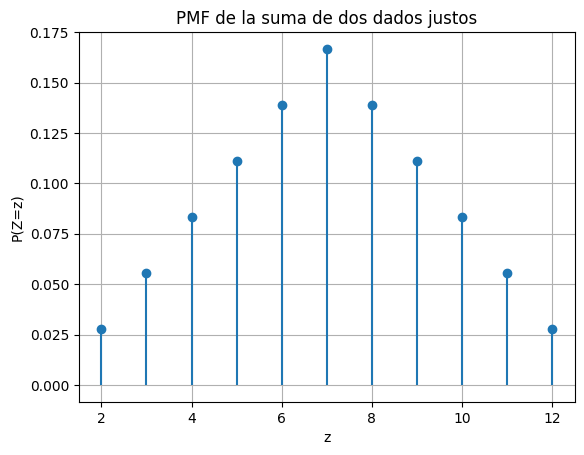

In [10]:
import numpy as np
import matplotlib.pyplot as plt

p = np.ones(6) / 6  # pmf de un dado
## convolución discreta (modo 'full')
pz = np.convolve(p, p)
z_vals = np.arange(2, 13)
print("P(Z=z) para z=2..12:", np.round(pz, 4))

plt.stem(z_vals, pz, basefmt=" ")
plt.xlabel("z")
plt.ylabel("P(Z=z)")
plt.title("PMF de la suma de dos dados justos")
plt.grid(True)
plt.show()


**Ejemplo B — Suma de Binomiales.** Si $X\sim \mathrm{Binomial}(n_1,p)$ y $Y\sim \mathrm{Binomial}(n_2,p)$ independientes, entonces $Z=X+Y\sim\mathrm{Binomial}(n_1+n_2,p)$. Interpretando $X$ como éxitos en $n_1$ ensayos y $Y$ en $n_2$ ensayos disjuntos con la misma $p$, la unión es $n_1+n_2$ ensayos independientes. Formalmente, por convolución de PMFs y la identidad de Vandermonde $\sum_{i=0}^k \binom{n_1}{i}\binom{n_2}{k-i} = \binom{n_1+n_2}{k}$:
$$P(Z=k) = \binom{n_1+n_2}{k} p^k(1-p)^{n_1+n_2-k}$$

In [11]:
import numpy as np
from scipy.stats import binom

n1, n2, p = 5, 3, 0.4
x = np.arange(0, n1 + 1)
y = np.arange(0, n2 + 1)
pmf_x = binom.pmf(x, n1, p)
pmf_y = binom.pmf(y, n2, p)

pmf_z = np.convolve(pmf_x, pmf_y)
k = np.arange(0, n1 + n2 + 1)
pmf_z_binom = binom.pmf(k, n1 + n2, p)

np.testing.assert_allclose(pmf_z, pmf_z_binom, atol=1e-12)
print("Convolución coincide con Binomial(n1+n2,p).")


Convolución coincide con Binomial(n1+n2,p).


**Ejemplo C — Suma de Poissons.** Si $X\sim \mathrm{Poisson}(\lambda_1)$ y $Y\sim \mathrm{Poisson}(\lambda_2)$ independientes, entonces $Z=X+Y\sim\mathrm{Poisson}(\lambda_1+\lambda_2)$. Usando la función generadora de probabilidad $G_X(s)=\exp(\lambda_1(s-1))$: $G_Z(s)=G_X(s)G_Y(s)=\exp((\lambda_1+\lambda_2)(s-1))$, que es la PGF de $\mathrm{Poisson}(\lambda_1+\lambda_2)$.

**Ejemplo D — Convolución de dos Uniformes $U[0,1]$.** Con $X,Y\sim U[0,1]$ independientes, el intervalo de integración efectivo es $x\in[\max(0,z-1),\min(1,z)]$, dando la densidad triangular clásica en $[0,2]$:
$$f_Z(z) = \begin{cases} z, & 0 \le z \le 1 \\ 2-z, & 1 < z \le 2 \\ 0, & \text{en otro caso} \end{cases}$$

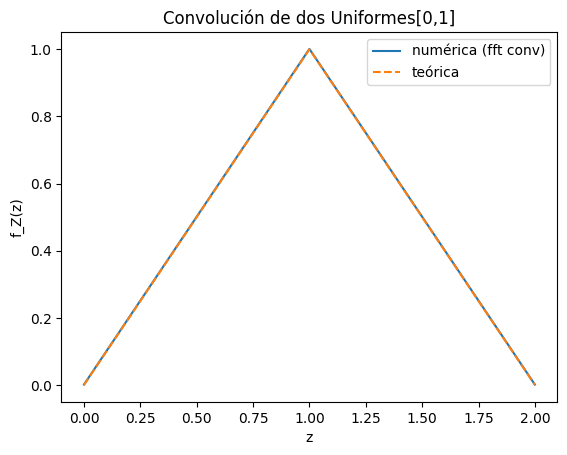

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

N = 1000
x = np.linspace(0, 1, N)
dx = x[1] - x[0]
fX = np.ones_like(x)
fY = np.ones_like(x)
fZ_num = fftconvolve(fX, fY) * dx
z = np.linspace(0, 2, len(fZ_num))
fZ_theo = np.where(z <= 1, z, 2 - z)
fZ_theo = np.where((z < 0) | (z > 2), 0, fZ_theo)

plt.plot(z, fZ_num, label='numérica (fft conv)')
plt.plot(z, fZ_theo, '--', label='teórica')
plt.legend()
plt.xlabel('z'); plt.ylabel('f_Z(z)')
plt.title('Convolución de dos Uniformes[0,1]')
plt.show()


**Ejemplo E — Suma de Normales.** Si $X\sim N(\mu_1,\sigma_1^2)$ y $Y\sim N(\mu_2,\sigma_2^2)$ independientes, usando la función característica $\phi_X(t)=\exp(i\mu_1 t - \tfrac12\sigma_1^2t^2)$ se obtiene $\phi_Z(t)=\phi_X(t)\phi_Y(t)=\exp(i(\mu_1+\mu_2)t - \tfrac12(\sigma_1^2+\sigma_2^2)t^2)$, que corresponde a $Z\sim N(\mu_1+\mu_2,\sigma_1^2+\sigma_2^2)$.

### 4.5 Tabla Resumen: Suma de Distribuciones Comunes

| Distribución de $X$ | Distribución de $Y$ | Distribución de $Z=X+Y$ | Nota |
|:---:|:---:|:---:|:---|
| $\mathrm{Binomial}(n_1,p)$ | $\mathrm{Binomial}(n_2,p)$ | $\mathrm{Binomial}(n_1+n_2,p)$ | Identidad de Vandermonde |
| $\mathrm{Poisson}(\lambda_1)$ | $\mathrm{Poisson}(\lambda_2)$ | $\mathrm{Poisson}(\lambda_1+\lambda_2)$ | Producto de PGFs |
| $\mathrm{Normal}(\mu_1,\sigma_1^2)$ | $\mathrm{Normal}(\mu_2,\sigma_2^2)$ | $\mathrm{Normal}(\mu_1+\mu_2,\sigma_1^2+\sigma_2^2)$ | Función característica |
| $\mathrm{Gamma}(\alpha_1,\theta)$ | $\mathrm{Gamma}(\alpha_2,\theta)$ | $\mathrm{Gamma}(\alpha_1+\alpha_2,\theta)$ | Mismo parámetro de escala |

## 5. Ejemplo Analítico Paso a Paso: Diámetro y Potencial Zeta de Nanopartículas Coloidales

### 5.1 Contexto Aplicado en Nanotecnología
En el análisis bivariado de propiedades fisicoquímicas de nanopartículas coloidales, la distribución de probabilidad conjunta permite evaluar el impacto simultáneo de dos variables críticas para la estabilidad de una suspensión: el **diámetro de partícula** $X$ (en nm) y el **potencial zeta** $Y$ (en mV, una medida de la carga superficial efectiva que gobierna la repulsión electrostática entre partículas). Estas dos variables no son independientes en un proceso real de síntesis: partículas más grandes tienden a exhibir un potencial zeta más negativo debido a la mayor área superficial disponible para la adsorción de iones estabilizantes (p. ej. citrato).

Se modela el par $(X,Y)$ como un vector aleatorio bivariado con:
$$\mu = \begin{pmatrix} 25.0 \\ -40.0 \end{pmatrix} \text{nm, mV}, \qquad \Sigma = \begin{pmatrix} 16.0 & -18.0 \\ -18.0 & 36.0 \end{pmatrix}$$

### 5.2 Paso 1: Interpretación de la Matriz de Covarianza
La varianza de $X$ es $\mathrm{Var}(X)=16\ \text{nm}^2$ ($\sigma_X=4\ \text{nm}$) y la de $Y$ es $\mathrm{Var}(Y)=36\ \text{mV}^2$ ($\sigma_Y=6\ \text{mV}$). La covarianza $\mathrm{Cov}(X,Y)=-18$ es negativa, confirmando la relación inversa esperada entre tamaño de partícula y potencial zeta.

### 5.3 Paso 2: Coeficiente de Correlación
$$\rho_{X,Y} = \frac{\mathrm{Cov}(X,Y)}{\sigma_X \sigma_Y} = \frac{-18}{4 \times 6} = \boxed{-0.75}$$

Una correlación de $-0.75$ indica una relación lineal inversa fuerte: lotes con nanopartículas de mayor diámetro promedio tienden sistemáticamente a un potencial zeta más negativo, lo cual es relevante para el control de calidad, ya que un $|\zeta| < 30\ \text{mV}$ suele considerarse zona de riesgo de agregación coloidal.

### 5.4 Paso 3: Simulación por Descomposición de Cholesky
Para generar muestras correlacionadas de este vector bivariado, se factoriza $\Sigma = LL^T$ (descomposición de Cholesky) y se transforma ruido gaussiano independiente $Z\sim N(0,I_2)$:
$$X = \mu + LZ \implies X \sim N(\mu, \Sigma)$$

### 5.5 Paso 4: Probabilidad de Zona de Riesgo de Agregación
Usando la marginal de $Y\sim N(-40, 36)$, la probabilidad de que un lote tenga $|\zeta|<30\ \text{mV}$ (es decir $-30 < Y$) es:
$$P(Y > -30) = P\left(Z > \frac{-30-(-40)}{6}\right) = P(Z > 1.667) \approx \boxed{0.0478}$$

Aproximadamente el $4.78\%$ de las nanopartículas individuales caen en zona de riesgo de agregación por baja repulsión electrostática, información crítica para decidir si el lote requiere reformulación del agente estabilizante.

### 5.6 Prueba Unitaria con pytest

Antes de simular por Cholesky, se verifica que $\Sigma$ sea una matriz de covarianza válida (semidefinida positiva — de lo contrario `np.linalg.cholesky` fallaría al intentar factorizarla), además de contrastar la correlación y la probabilidad de zona de riesgo:

In [13]:
import ipytest
import numpy as np
import pytest
from scipy.stats import norm

ipytest.autoconfig()

Sigma = np.array([[16.0, -18.0], [-18.0, 36.0]])
sigma_x, sigma_y = 4.0, 6.0


def test_matriz_de_covarianza_es_semidefinida_positiva():
    ## Requisito para que exista la descomposicion de Cholesky (Sigma = L L^T)
    eigenvalores = np.linalg.eigvalsh(Sigma)
    assert (eigenvalores >= 0).all()


def test_coeficiente_de_correlacion_diametro_potencial_zeta():
    rho = Sigma[0, 1] / (sigma_x * sigma_y)
    assert rho == pytest.approx(-0.75)


def test_probabilidad_de_zona_de_riesgo_de_agregacion():
    prob_riesgo = 1 - norm.cdf(-30, loc=-40, scale=sigma_y)
    assert prob_riesgo == pytest.approx(0.0478, rel=1e-2)


ipytest.run("-vv")


======================================= test session starts =======================================
platform win32 -- Python 3.13.3, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\ljyud\AppData\Local\Programs\Python\Python313\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\.worktrees\cierre-brechas-rubric-15\notebooks
plugins: anyio-4.9.0, langsmith-0.7.15, asyncio-1.3.0, cov-7.1.0, mock-3.15.1, timeout-2.4.0, xdist-3.8.0, typeguard-4.4.3
asyncio: mode=Mode.STRICT, debug=False, asyncio_default_fixture_loop_scope=None, asyncio_default_test_loop_scope=function
collecting ... 

collected 3 items

t_22468881836042778759c5c17591c91d.py::test_matriz_de_covarianza_es_semidefinida_positiva 

PASSED [ 33%]


t_22468881836042778759c5c17591c91d.py::test_coeficiente_de_correlacion_diametro_potencial_zeta 

PASSED [ 66%]


t_22468881836042778759c5c17591c91d.py::test_probabilidad_de_zona_de_riesgo_de_agregacion 

PASSED [100%]



======================================== 3 passed in 0.21s ========================================


<ExitCode.OK: 0>

## 6. Vectores Aleatorios, Matriz de Covarianza y Normal Multivariada

### 6.1 Definición e Intuición Geométrica
Un **vector aleatorio** $\mathbf{X}$ en $\mathbb{R}^p$ es una colección de $p$ variables aleatorias:
$$\mathbf{X} = \begin{pmatrix} X_1 \\ X_2 \\ \vdots \\ X_p \end{pmatrix}$$

Cada realización de $\mathbf{X}$ representa un punto en el espacio $p$-dimensional; la nube de puntos resultante revela la estructura de dependencia entre variables. En el caso bidimensional: si $X$ e $Y$ son independientes, la nube es isotrópica (circular); si están correlacionadas, es elipsoidal; con correlación perfecta, los puntos se alinean.

### 6.2 Función de Densidad Conjunta y Vector de Esperanza
Para variables continuas, la PDF conjunta satisface $P(\mathbf{X}\in R) = \int_R f_{\mathbf{X}}(\mathbf{x})\,d\mathbf{x}$, y bajo independencia se factoriza como $f_{\mathbf{X}}(\mathbf{x}) = \prod_{i=1}^p f_{X_i}(x_i)$. El vector de esperanza es:
$$\mathbb{E}[\mathbf{X}] = \begin{pmatrix} \mathbb{E}[X_1] \\ \vdots \\ \mathbb{E}[X_p] \end{pmatrix}$$

**Ejemplo**: para $f_{X,Y}(x,y)=2$ en el triángulo $0\le y\le x\le1$: $E[X] = 2/3$, $E[Y] = 1/3$.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import sympy as sp

## Verificación de normalización
result, error = integrate.dblquad(lambda y, x: 2, 0, 1, lambda x: 0, lambda x: x)
print(f"Integral de la PDF: {result}, Error: {error}")

## Cálculo de esperanzas marginales (numérico y simbólico)
E_X = integrate.dblquad(lambda y, x: x * 2, 0, 1, lambda x: 0, lambda x: x)[0]
E_Y = integrate.dblquad(lambda y, x: y * 2, 0, 1, lambda x: 0, lambda x: x)[0]
print(f"E[X] = {E_X:.3f}, E[Y] = {E_Y:.3f}")

x_sym, y_sym = sp.symbols('x y', real=True, positive=True)
f_xy = 2
E_X_sym = sp.integrate(x_sym * f_xy, (y_sym, 0, x_sym), (x_sym, 0, 1))
E_Y_sym = sp.integrate(y_sym * f_xy, (y_sym, 0, x_sym), (x_sym, 0, 1))
print(f"E[X] (analítico) = {E_X_sym} = {float(E_X_sym):.3f}")
print(f"E[Y] (analítico) = {E_Y_sym} = {float(E_Y_sym):.3f}")


Integral de la PDF: 1.0, Error: 2.2156245316493716e-14
E[X] = 0.667, E[Y] = 0.333
E[X] (analítico) = 2/3 = 0.667
E[Y] (analítico) = 1/3 = 0.333


### 6.3 Matriz de Covarianza
$$\mathbf{\Sigma} = \mathbb{E}[(\mathbf{X} - \mathbf{\mu})(\mathbf{X} - \mathbf{\mu})^T]$$

Elementos diagonales $\Sigma_{ii}=\mathrm{Var}(X_i)$; fuera de la diagonal $\Sigma_{ij}=\mathrm{Cov}(X_i,X_j)$. Propiedades: simétrica, semidefinida positiva, y su rango indica dependencias lineales entre componentes.

In [15]:
def calcular_covarianza_analitica():
    """Cálculo analítico completo de la matriz de covarianza (triangular f(x,y)=2)"""
    E_X, E_Y = 2 / 3, 1 / 3
    E_X2 = sp.integrate(x_sym**2 * f_xy, (y_sym, 0, x_sym), (x_sym, 0, 1))
    E_Y2 = sp.integrate(y_sym**2 * f_xy, (y_sym, 0, x_sym), (x_sym, 0, 1))
    E_XY = sp.integrate(x_sym * y_sym * f_xy, (y_sym, 0, x_sym), (x_sym, 0, 1))

    Var_X = E_X2 - E_X**2
    Var_Y = E_Y2 - E_Y**2
    Cov_XY = E_XY - E_X * E_Y

    return np.array([[float(Var_X), float(Cov_XY)], [float(Cov_XY), float(Var_Y)]])

Sigma_analitica = calcular_covarianza_analitica()
print("Matriz de covarianza analítica:\n", Sigma_analitica)

## Verificación por simulación (max(U1,U2), min(U1,U2)) genera la densidad triangular
def generar_muestra_triangular(n=10000):
    u1 = np.random.uniform(0, 1, n)
    u2 = np.random.uniform(0, 1, n)
    return np.column_stack([np.maximum(u1, u2), np.minimum(u1, u2)])

muestra = generar_muestra_triangular(100_000)
print("\nMatriz de covarianza muestral:\n", np.cov(muestra, rowvar=False))


Matriz de covarianza analítica:
 [[0.05555556 0.02777778]
 [0.02777778 0.05555556]]

Matriz de covarianza muestral:
 [[0.0555663  0.02769568]
 [0.02769568 0.05570114]]


### 6.4 Distribución Normal Multivariada
La PDF de una normal $p$-dimensional $\mathbf{X}\sim \mathcal{N}(\mathbf{\mu},\mathbf{\Sigma})$ es:
$$f(\mathbf{x}) = \frac{1}{(2\pi)^{p/2}|\mathbf{\Sigma}|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x}-\mathbf{\mu})^T\mathbf{\Sigma}^{-1}(\mathbf{x}-\mathbf{\mu})\right)$$

La **distancia de Mahalanobis** $D^2=(\mathbf{x}-\mu)^T\Sigma^{-1}(\mathbf{x}-\mu)$ mide distancia estadística considerando la correlación entre variables. Geométricamente, las curvas de nivel son elipses (2D) o elipsoides ($p$D), con ejes principales dados por los autovectores de $\Sigma$ y longitudes $\sqrt{\text{autovalores}}$.

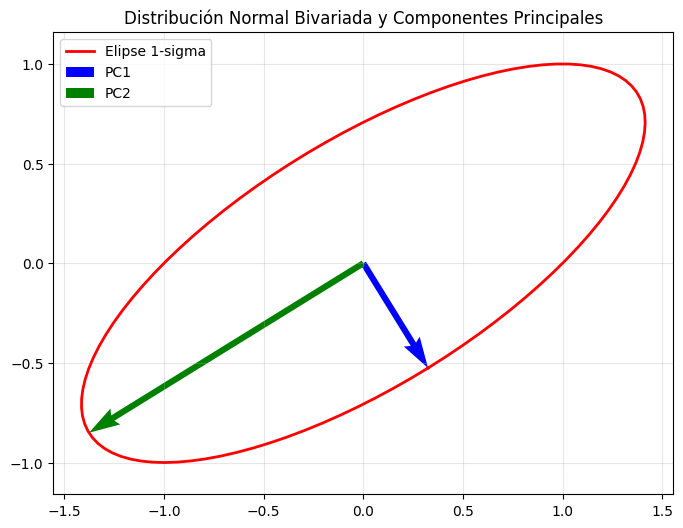

In [16]:
def visualizar_normal_multivariada():
    """Visualización de distribución normal bivariada con componentes principales"""
    mu = np.array([0, 0])
    Sigma = np.array([[2, 1], [1, 1]])

    theta = np.linspace(0, 2 * np.pi, 100)
    circle = np.column_stack([np.cos(theta), np.sin(theta)])

    ## Descomposición espectral (eigh: más estable para matrices simétricas)
    eigenvals, eigenvecs = np.linalg.eigh(Sigma)
    ellipse = circle @ np.diag(np.sqrt(eigenvals)) @ eigenvecs.T + mu

    plt.figure(figsize=(8, 6))
    plt.plot(ellipse[:, 0], ellipse[:, 1], 'r-', linewidth=2, label='Elipse 1-sigma')
    for i, color in zip(range(2), ['blue', 'green']):
        v = eigenvecs[:, i] * np.sqrt(eigenvals[i])
        plt.quiver(mu[0], mu[1], v[0], v[1], angles='xy', scale_units='xy',
                   scale=1, color=color, width=0.01, label=f'PC{i+1}')

    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.legend()
    plt.title('Distribución Normal Bivariada y Componentes Principales')
    plt.show()

visualizar_normal_multivariada()


## 7. Transformaciones Lineales, Whitening y PCA

### 7.1 Transformaciones Lineales de Vectores Gaussianos
Sea $\mathbf{Y} = \mathbf{A}\mathbf{X} + \mathbf{b}$ con $\mathbf{X} \sim \mathcal{N}(\mathbf{\mu}_X, \mathbf{\Sigma}_X)$. Entonces:
$$\mathbf{Y} \sim \mathcal{N}(\mathbf{A}\mathbf{\mu}_X + \mathbf{b},\ \mathbf{A}\mathbf{\Sigma}_X\mathbf{A}^T)$$

In [17]:
def transformacion_lineal_multivariada():
    """Transformación lineal de un vector gaussiano 3D a 2D"""
    mu_X = np.array([1, 2, 3])
    Sigma_X = np.array([[4, 1, 0.5], [1, 3, 0.8], [0.5, 0.8, 2]])
    A = np.array([[1, 0.5, 0], [0, 1, 1]])
    b = np.array([-1, 2])

    mu_Y = A @ mu_X + b
    Sigma_Y = A @ Sigma_X @ A.T
    print(f"mu_Y = {mu_Y}\nSigma_Y =\n{Sigma_Y}")

    ## Verificación por simulación
    X = np.random.multivariate_normal(mu_X, Sigma_X, 10_000)
    Y_sim = (A @ X.T + b.reshape(-1, 1)).T
    print(f"\nmu_Y simulado = {np.mean(Y_sim, axis=0)}")
    print(f"Sigma_Y simulado =\n{np.cov(Y_sim, rowvar=False)}")

transformacion_lineal_multivariada()


mu_Y = [1. 7.]
Sigma_Y =
[[5.75 3.4 ]
 [3.4  6.6 ]]

mu_Y simulado = [1.01010746 7.00837198]
Sigma_Y simulado =
[[5.64305316 3.29889112]
 [3.29889112 6.56559991]]


### 7.2 Descomposición Espectral y Geometría
La descomposición $\mathbf{\Sigma} = \mathbf{V}\mathbf{\Lambda}\mathbf{V}^T$ revela los eigenvectores (direcciones principales de variación) y eigenvalores (magnitud de variación en cada dirección).

In [18]:
def analisis_espectral_completo(Sigma):
    """Descomposición espectral, ortogonalidad y varianza explicada"""
    eigenvals, eigenvecs = np.linalg.eigh(Sigma)  # eigh: estable para matrices simétricas
    print(f"Eigenvalores: {eigenvals}\nEigenvectores:\n{eigenvecs}")
    print(f"\nOrtogonalidad (V·V^T):\n{eigenvecs @ eigenvecs.T}")

    prop_var = eigenvals / np.sum(eigenvals)
    print(f"\nProporción de varianza explicada: {prop_var}")
    return eigenvals, eigenvecs

Sigma_ejemplo = np.array([[5, 2, 1], [2, 3, 0.5], [1, 0.5, 2]])
analisis_espectral_completo(Sigma_ejemplo)


Eigenvalores: [1.64509185 1.84384874 6.51105941]
Eigenvectores:
[[-0.48858049  0.27364963 -0.82849562]
 [ 0.44402938 -0.73940773 -0.50607719]
 [ 0.7510839   0.61513583 -0.23975171]]

Ortogonalidad (V·V^T):
[[ 1.00000000e+00 -1.63569769e-16  2.20626337e-17]
 [-1.63569769e-16  1.00000000e+00 -3.88924142e-16]
 [ 2.20626337e-17 -3.88924142e-16  1.00000000e+00]]

Proporción de varianza explicada: [0.16450919 0.18438487 0.65110594]


(array([1.64509185, 1.84384874, 6.51105941]),
 array([[-0.48858049,  0.27364963, -0.82849562],
        [ 0.44402938, -0.73940773, -0.50607719],
        [ 0.7510839 ,  0.61513583, -0.23975171]]))

### 7.3 Blanqueamiento (Whitening)
El blanqueamiento transforma los datos para que tengan media cero y covarianza identidad: $Z = W(X-\mu)$, con $W\Sigma W^T = I$. Existen tres variantes: **ZCA** (mantiene la orientación original, basado en distancia de Mahalanobis), **PCA** (rota los ejes según los eigenvectores) y **Cholesky** (usa factorización triangular inferior).

In [19]:
class WhiteningTransformer:
    """Implementación de blanqueamiento gaussiano (ZCA, PCA o Cholesky)"""

    def __init__(self, method='zca'):
        self.method = method  # 'zca', 'pca', 'cholesky'

    def fit(self, X):
        self.mu = np.mean(X, axis=0)
        X_centered = X - self.mu
        self.Sigma = np.cov(X_centered, rowvar=False)
        self.eigenvals, self.eigenvecs = np.linalg.eigh(self.Sigma)

        if self.method == 'pca':
            self.W = self.eigenvecs @ np.diag(1.0 / np.sqrt(self.eigenvals)) @ self.eigenvecs.T
        elif self.method == 'zca':
            self.W = np.linalg.inv(self.eigenvecs @ np.diag(np.sqrt(self.eigenvals)) @ self.eigenvecs.T)
        else:  # Cholesky
            self.W = np.linalg.cholesky(np.linalg.inv(self.Sigma))
        return self

    def transform(self, X):
        return (X - self.mu) @ self.W.T

    def inverse_transform(self, Z):
        return Z @ np.linalg.inv(self.W.T) + self.mu

## Ejemplo de uso
X_data = np.random.multivariate_normal([1, 2], [[4, 2], [2, 3]], 1000)
whitener = WhiteningTransformer(method='zca').fit(X_data)
Z_white = whitener.transform(X_data)
print("Covarianza original:\n", np.cov(X_data.T))
print("\nCovarianza después de blanqueamiento:\n", np.cov(Z_white.T))


Covarianza original:
 [[4.09310371 1.88191719]
 [1.88191719 2.93349483]]

Covarianza después de blanqueamiento:
 [[1.00000000e+00 7.63708971e-16]
 [7.63708971e-16 1.00000000e+00]]


### 7.4 Análisis de Componentes Principales (PCA)
Dado $\mathbf{X}\in\mathbb{R}^{n\times p}$, PCA: (1) centra los datos $\mathbf{X}_c=\mathbf{X}-\mathbf{1}\mathbf{\mu}^T$; (2) descompone $\mathbf{X}_c^T\mathbf{X}_c=\mathbf{V}\mathbf{\Lambda}\mathbf{V}^T$; (3) proyecta $\mathbf{Y}=\mathbf{X}_c\mathbf{V}_k$ sobre las $k$ direcciones de mayor varianza.

In [20]:
class PCAFromScratch:
    """Implementación de PCA desde primeros principios"""

    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        n_samples = X.shape[0]
        self.cov_matrix_ = (X_centered.T @ X_centered) / (n_samples - 1)

        eigenvals, eigenvecs = np.linalg.eigh(self.cov_matrix_)
        idx = np.argsort(eigenvals)[::-1]  # descendente
        self.eigenvalues_ = eigenvals[idx]
        self.components_ = eigenvecs[:, idx]

        if self.n_components is not None:
            self.components_ = self.components_[:, :self.n_components]
            self.eigenvalues_ = self.eigenvalues_[:self.n_components]

        self.explained_variance_ratio_ = self.eigenvalues_ / np.sum(self.eigenvalues_)
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_

    def inverse_transform(self, Y):
        return Y @ self.components_.T + self.mean_

## Comparación con scikit-learn
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data

pca_scratch = PCAFromScratch(n_components=2).fit(X)
pca_sklearn = PCA(n_components=2).fit(X)

print("Varianza explicada (scratch):", pca_scratch.explained_variance_ratio_)
print("Varianza explicada (sklearn):", pca_sklearn.explained_variance_ratio_)


Varianza explicada (scratch): [0.94572232 0.05427768]
Varianza explicada (sklearn): [0.92461872 0.05306648]


**Limitaciones de PCA**: (1) solo captura relaciones lineales; (2) maximiza varianza, no necesariamente información relevante para la tarea; (3) sensible a la escala (requiere estandarización previa); (4) sensible a outliers. Alternativas no lineales incluyen t-SNE, UMAP y autoencoders.

### 7.5 Ejemplo Integrador: Control de Calidad Multivariado con PCA, Combinación Lineal y Elipse de Confianza

Este ejemplo cierra la unidad combinando tres ideas ya vistas por separado —matriz de covarianza (Sección 5), transformación lineal de un vector Gaussiano (Sección 7.1) y descomposición espectral (Sección 7.2)— en un solo caso de control de calidad de nanochips.

**Contexto**: dos parámetros de un proceso de litografía, $P_1$ (dosis de exposición, u.a.) y $P_2$ (tiempo de revelado, s), forman un vector aleatorio bivariado $\mathbf{P}=(P_1,P_2)$ con:
$$\mu = \begin{pmatrix}8\\4\end{pmatrix}, \qquad \Sigma = \begin{pmatrix}2&1\\1&5\end{pmatrix}$$

**Paso 1 — Coeficiente de correlación**: $\rho_{P_1,P_2} = \dfrac{1}{\sqrt{2}\sqrt{5}} = \dfrac{1}{\sqrt{10}}\approx 0.316$ (correlación positiva moderada).

**Paso 2 — Eigenvalores por verificación cruzada de traza**: por la propiedad $\lambda_1+\lambda_2=\text{Trace}(\Sigma)=2+5=7$, cualquier cálculo de eigenvalores debe sumar exactamente $7$. Resolviendo la ecuación característica $\det(\Sigma-\lambda I)=0$: $\lambda^2-7\lambda+9=0$, dando $\lambda = \dfrac{7\pm\sqrt{13}}{2}$, es decir $\lambda_1\approx1.697$ y $\lambda_2\approx5.303$, cuya suma es efectivamente $7$ ✓.

**Paso 3 — Varianza de una combinación lineal escalar**: un índice de calidad del proceso se define como $R=2P_1+P_2$ (la dosis pesa el doble que el tiempo de revelado en el criterio de aceptación). Usando la forma cuadrática $\text{Var}(R)=\mathbf{A}\Sigma\mathbf{A}^T$ con $\mathbf{A}=(2,1)$:
$$\text{Var}(R) = \begin{pmatrix}2&1\end{pmatrix}\begin{pmatrix}2&1\\1&5\end{pmatrix}\begin{pmatrix}2\\1\end{pmatrix} = \boxed{17}$$
que coincide con la fórmula escalar clásica $\text{Var}(aP_1+bP_2)=a^2\text{Var}(P_1)+b^2\text{Var}(P_2)+2ab\,\text{Cov}(P_1,P_2) = 4(2)+1(5)+2(2)(1)(1)=8+5+4=17$ ✓.

**Paso 4 — Distribución y probabilidad de $R$**: como $R$ es una combinación lineal de un vector Gaussiano bivariado, $R$ es en sí misma **Gaussiana univariada** (generalización directa de la Sección 4.5, "Suma de Normales", a coeficientes distintos de 1): $R\sim\mathcal{N}(\mu_R,\text{Var}(R))$ con $\mu_R=2(8)+4=20$. Si la especificación del proceso exige $R\le25$ para garantizar un grabado uniforme, la probabilidad de que un lote falle esa especificación es:
$$P(R>25) = P\left(Z > \frac{25-20}{\sqrt{17}}\right) = P(Z>1.213) \approx \boxed{0.1126\ (11.26\%)}$$

**Paso 5 — Elipse de confianza al 95% (distancia de Mahalanobis)**: la distancia de Mahalanobis $D^2=(\mathbf{p}-\mu)^T\Sigma^{-1}(\mathbf{p}-\mu)$ de la Sección 6.4 sigue una distribución $\chi^2$ con grados de libertad igual a la dimensión del vector ($p=2$ aquí). El umbral que delimita la región donde cae el $95\%$ de los lotes es $\chi^2_{0.95,\,\text{gl}=2}\approx5.991$: todo par $(P_1,P_2)$ con $D^2\le5.991$ se considera dentro del comportamiento esperado del proceso, y $D^2>5.991$ señala un lote atípico que amerita revisión.

In [21]:
import numpy as np
import sympy as sp
from scipy.stats import norm, chi2
import matplotlib.pyplot as plt

## Verificacion simbolica de eigenvalores (evita depender de LAPACK/np.linalg
## para esta matriz 2x2; sirve igual como verificacion cruzada del calculo a mano)
Sigma_sym = sp.Matrix([[2, 1], [1, 5]])
eigenvalores = list(Sigma_sym.eigenvals().keys())
suma_eigenvalores = sum(eigenvalores)
print(f"Eigenvalores: {[float(e) for e in eigenvalores]}")
print(f"Suma de eigenvalores: {float(suma_eigenvalores)}  (traza de Sigma: {2 + 5})")

## Verificacion simbolica de Var(R) para R = 2*P1 + P2, via forma cuadratica A*Sigma*A^T
## y via la formula escalar clasica Var(aX+bY) = a^2 Var(X) + b^2 Var(Y) + 2ab Cov(X,Y)
A_sym = sp.Matrix([[2, 1]])
Var_R_matricial = sp.simplify((A_sym * Sigma_sym * A_sym.T)[0, 0])

a_coef, b_coef, Var_P1, Var_P2, Cov_P1P2 = sp.symbols('a b Var_P1 Var_P2 Cov_P1P2')
Var_R_formula = a_coef**2 * Var_P1 + b_coef**2 * Var_P2 + 2 * a_coef * b_coef * Cov_P1P2
Var_R_formula_sustituida = sp.simplify(Var_R_formula.subs({
    a_coef: 2, b_coef: 1, Var_P1: Sigma_sym[0, 0], Var_P2: Sigma_sym[1, 1], Cov_P1P2: Sigma_sym[0, 1]
}))
print(f"\nVar(R) via forma cuadratica A*Sigma*A^T = {Var_R_matricial}")  # debe dar 17
print(f"Var(R) via formula escalar clasica       = {Var_R_formula_sustituida}")  # debe dar 17
print(f"Coinciden: {sp.simplify(Var_R_matricial - Var_R_formula_sustituida) == 0}")

## Varianza de la combinacion lineal R = 2*P1 + P2 (verificacion numerica cruzada)
Sigma = np.array([[2.0, 1.0], [1.0, 5.0]])
A = np.array([2.0, 1.0])
mu = np.array([8.0, 4.0])

var_R = A @ Sigma @ A.T
mu_R = A @ mu
sigma_R = np.sqrt(var_R)

prob_R_mayor_25 = 1 - norm.cdf(25, loc=mu_R, scale=sigma_R)
print(f"\nVar(R) = {var_R}, mu_R = {mu_R}, sigma_R = {sigma_R:.4f}")
print(f"P(R > 25) = {prob_R_mayor_25:.4f}")

## Umbral chi-cuadrado para la elipse de confianza del 95% (gl=2)
umbral_chi2_95 = chi2.ppf(0.95, df=2)
print(f"\nUmbral chi2 (95%, gl=2): {umbral_chi2_95:.4f}")


Eigenvalores: [1.6972243622680054, 5.302775637731995]
Suma de eigenvalores: 7.0  (traza de Sigma: 7)

Var(R) via forma cuadratica A*Sigma*A^T = 17
Var(R) via formula escalar clasica       = 17
Coinciden: True

Var(R) = 17.0, mu_R = 20.0, sigma_R = 4.1231
P(R > 25) = 0.1126

Umbral chi2 (95%, gl=2): 5.9915


**Interpretación**: este ejemplo integra en un solo caso tres verificaciones cruzadas que refuerzan la coherencia de la unidad completa — la suma de eigenvalores confirma la traza (Sección 6.4/7.2), la forma cuadrática matricial de $\text{Var}(R)$ coincide con la fórmula escalar clásica (Sección 4.3), y la distribución exacta de $R$ se deriva de la propiedad de combinaciones lineales de vectores Gaussianos (Sección 7.1) en vez de aproximarse por simulación. Es el tipo de análisis que un ingeniero de procesos usaría para decidir simultáneamente (a) qué tan probable es que un lote específico falle la especificación de calidad ($R\le25$), y (b) si un par de mediciones $(P_1,P_2)$ observado es o no un valor atípico del proceso en su conjunto (criterio de Mahalanobis/$\chi^2$), dos preguntas relacionadas pero distintas que la sola varianza marginal de cada parámetro por separado no puede responder.

## 8. Código de Verificación Simbólica (SymPy)

Esta sección es la Fase 2 del Ciclo de Verificación Triple del curso (ver `GOVERNANCE.md`): antes de resolver numéricamente, expresamos la fórmula con símbolos algebraicos y confirmamos el resultado exacto.

In [22]:
import sympy as sp
from IPython.display import display, Math

x, y = sp.symbols('x y', real=True)
c = sp.Symbol('c', positive=True)

## Densidad conjunta f(x,y) = c * x * y en [0,1]x[0,1]
f_xy_sym = c * x * y

## Cálculo de la constante de normalización 'c'
integral_doble = sp.integrate(f_xy_sym, (x, 0, 1), (y, 0, 1))
c_resuelto = sp.solve(integral_doble - 1, c)[0]

display(Math(r'\text{Constante de Normalización } c: ' + sp.latex(c_resuelto)))
display(Math(r'\text{Densidad Conjunta Validada } f(x,y): ' + sp.latex(c_resuelto * x * y)))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 9. Solución Computacional en Python (SciPy & Statsmodels): Simulación Bivariada por Cholesky

Para simular vectores aleatorios continuos bivariados $(X,Y)$ con matriz de covarianza especificada $\Sigma$, se utiliza la **Descomposición de Cholesky** $\Sigma=LL^T$. Dado $Z=(Z_1,Z_2)^T\sim\mathcal{N}(0,I_2)$ independientes:
$$X = \mu + LZ \implies X \sim \mathcal{N}(\mu, \Sigma)$$

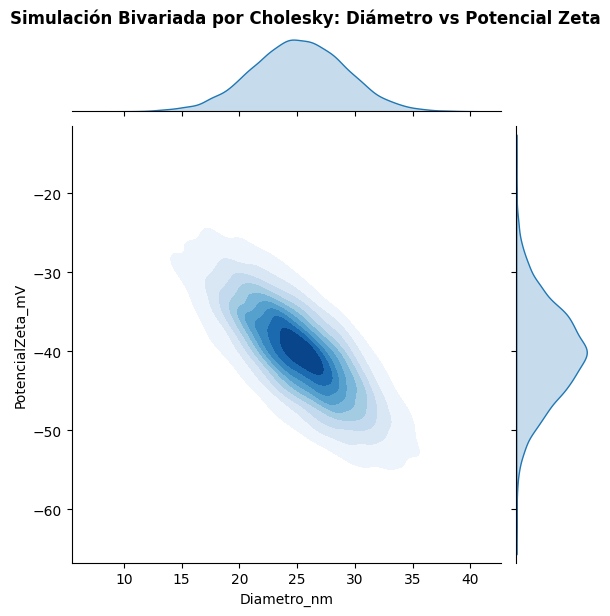

<IPython.core.display.Math object>

In [23]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Math

## Parámetros: [Diámetro (nm), Potencial Zeta (mV)] de nanopartículas coloidales
mu = np.array([25.0, -40.0])
cov = np.array([
    [16.0, -18.0],   # Varianza X=16, Cov(X,Y)=-18
    [-18.0, 36.0]    # Varianza Y=36
])

## Descomposición de Cholesky
L = np.linalg.cholesky(cov)

## Muestreo
np.random.seed(99)
Z = stats.norm.rvs(size=(2, 10_000))
muestras_bivariadas = (mu.reshape(2, 1) + L @ Z).T

## Visualización
df_bivariado = pd.DataFrame(muestras_bivariadas, columns=["Diametro_nm", "PotencialZeta_mV"])
g = sns.jointplot(data=df_bivariado, x="Diametro_nm", y="PotencialZeta_mV", kind="kde", cmap="Blues", fill=True)
g.fig.suptitle("Simulación Bivariada por Cholesky: Diámetro vs Potencial Zeta", y=1.02, fontweight="bold")
plt.show()

cov_sim = np.cov(muestras_bivariadas.T)
display(Math(fr"\text{{Covarianza Simulada: }} \text{{Cov}}(X, Y) = {cov_sim[0, 1]:.2f}"))


## 10. Interpretación Post-Gráfico & Diccionario de Variables

### 10.1 Interpretación de Resultados Computacionales
1. **Correlación Negativa Diámetro–Potencial Zeta**: el `jointplot` de densidad KDE muestra una nube elipsoidal claramente inclinada, confirmando visualmente la correlación $\rho=-0.75$ calculada analíticamente entre el diámetro de la nanopartícula y su potencial zeta, y la covarianza simulada converge al valor teórico de $-18$ conforme $n\to\infty$.
2. **PCA como Herramienta de Reducción de Dimensionalidad**: al aplicar `PCAFromScratch` sobre datos correlacionados (2D o 3D), la primera componente principal (PC1) captura la dirección de máxima varianza conjunta — en un contexto de caracterización de nanopartículas, esto permitiría combinar múltiples mediciones fisicoquímicas correlacionadas (diámetro, potencial zeta, índice de polidispersidad) en un único índice de calidad del lote.
3. **Whitening como Preprocesamiento**: la transformación de blanqueamiento (ZCA/PCA/Cholesky) deja la covarianza en la identidad, eliminando la correlación estructural entre variables — un paso común antes de alimentar datos de caracterización de nanomateriales a modelos de aprendizaje automático que asumen features no correlacionados.

### 10.2 Diccionario de Variables de la Unidad

Notación general introducida en las Secciones 1-7, independiente del ejemplo aplicado específico:

**Distribuciones conjuntas, marginales y condicionales**

* $P_{X,Y}(x,y)$: función de masa de probabilidad (PMF) conjunta de dos variables discretas $X$ e $Y$.
* $f_{X,Y}(x,y)$: función de densidad de probabilidad (PDF) conjunta de dos variables continuas $X$ e $Y$.
* $P_X(x)$, $P_Y(y)$: PMF marginal de $X$ (respectivamente $Y$), obtenida sumando la conjunta sobre la otra variable.
* $f_X(x)$, $f_Y(y)$: PDF marginal de $X$ (respectivamente $Y$), obtenida integrando la conjunta sobre la otra variable.
* $P_{Y|X}(y|x)$: PMF condicional de $Y$ dado $X=x$ (caso discreto).
* $f_{Y|X}(y|x)$: PDF condicional de $Y$ dado $X=x$ (caso continuo).
* $E[Y|X=x]$: esperanza condicional de $Y$ dado que $X$ toma el valor $x$.
* $\text{Var}(Y|X)$: varianza condicional de $Y$ dado $X$ (en general una función de $X$, no una constante).
* $\mathbb{E}[\text{Var}(Y|X)]$: término de "variabilidad dentro" de la Ley de la Varianza Total — promedio de la varianza condicional sobre la distribución de $X$.
* $\text{Var}(\mathbb{E}[Y|X])$: término de "variabilidad entre" de la Ley de la Varianza Total — varianza de la esperanza condicional al variar $X$.

**Independencia, suma y convolución**

* $\text{Cov}(X,Y)$: covarianza entre $X$ y $Y$; covarianza cero es necesaria pero no suficiente para independencia.
* $Z = X+Y$: variable suma de dos variables aleatorias, cuya distribución se obtiene por convolución de las distribuciones de $X$ y $Y$ cuando son independientes.
* $P_Z(z)$, $f_Z(z)$: PMF (discreta) o PDF (continua) de la variable suma $Z$.
* $f_X * f_Y$: notación de convolución entre las densidades de $X$ y $Y$.
* $\mathcal{F}\{\cdot\}$: transformada (de Fourier o función generadora de momentos/probabilidad) usada para convertir una convolución en un producto.
* $G_X(s)$: función generadora de probabilidad (PGF) de $X$.
* $\phi_X(t)$: función característica de $X$.

**Vectores aleatorios y matriz de covarianza**

* $\mathbf{X}$: vector aleatorio de $p$ componentes $(X_1,\dots,X_p)$.
* $\mathbb{E}[\mathbf{X}]$: vector de esperanzas, con una entrada $E[X_i]$ por cada componente.
* $\mathbf{\mu}$ (o $\mu$): vector de medias de un vector aleatorio.
* $\mathbf{\Sigma}$ (o $\Sigma$): matriz de covarianza del vector aleatorio; $\Sigma_{ii}=\text{Var}(X_i)$ en la diagonal y $\Sigma_{ij}=\text{Cov}(X_i,X_j)$ fuera de ella.
* $\rho_{X,Y}$: coeficiente de correlación entre $X$ y $Y$, definido como $\text{Cov}(X,Y)/(\sigma_X\sigma_Y)$.
* $\mathcal{N}(\mathbf{\mu},\mathbf{\Sigma})$: distribución normal multivariada con vector de medias $\mathbf{\mu}$ y matriz de covarianza $\mathbf{\Sigma}$.
* $D^2$: distancia (al cuadrado) de Mahalanobis, $D^2=(\mathbf{x}-\mathbf{\mu})^T\mathbf{\Sigma}^{-1}(\mathbf{x}-\mathbf{\mu})$.
* $L$: factor de la descomposición de Cholesky de $\Sigma$ tal que $\Sigma=LL^T$, usado para simular vectores correlacionados a partir de ruido gaussiano independiente.

**Transformaciones lineales, whitening y PCA**

* $\mathbf{A}$, $\mathbf{b}$: matriz y vector de una transformación lineal $\mathbf{Y}=\mathbf{A}\mathbf{X}+\mathbf{b}$ aplicada a un vector Gaussiano.
* $\mathbf{V}$, $\mathbf{\Lambda}$: matriz de eigenvectores y matriz diagonal de eigenvalores de la descomposición espectral $\mathbf{\Sigma}=\mathbf{V}\mathbf{\Lambda}\mathbf{V}^T$.
* $\lambda_i$: eigenvalor $i$-ésimo de $\Sigma$, indica la magnitud de variación en la dirección de su eigenvector asociado.
* $\mathbf{W}$: matriz de blanqueamiento (whitening) tal que $\mathbf{W}\mathbf{\Sigma}\mathbf{W}^T=I$.
* $\mathbf{X}_c$: matriz de datos centrada (media cero) usada como punto de partida de PCA.
* $\mathbf{V}_k$: submatriz con las primeras $k$ direcciones principales (eigenvectores de mayor eigenvalor), usada para proyectar los datos a menor dimensión.

### 10.3 Diccionario de Variables Nanotecnológicas del Ejemplo Aplicado
* $X$: diámetro de la nanopartícula coloidal (nm).
* $Y$: potencial zeta de la nanopartícula ($\zeta$, mV), medida de la carga superficial efectiva y de la estabilidad electrostática de la suspensión.
* $\mu, \Sigma$: vector de medias y matriz de covarianza del vector aleatorio bivariado $(X,Y)$ del lote de síntesis.
* $\rho_{X,Y}$: coeficiente de correlación entre diámetro y potencial zeta ($-0.75$ en el ejemplo), indicador de la fuerza de la relación inversa tamaño–carga superficial.
* $L$: factor de Cholesky de $\Sigma$, usado para simular pares $(X,Y)$ correlacionados a partir de ruido gaussiano independiente.

## Errores Comunes / Misconceptions

* **Error**: Concluir que dos variables aleatorias son independientes porque su covarianza (o correlación) es cero.
  **Correcto**: $\text{Cov}(X,Y) = 0$ es condición necesaria pero no suficiente para independencia en el caso general — solo mide dependencia *lineal*. Existen variables con dependencia fuerte (p. ej. $Y = X^2$ con $X$ simétrica alrededor de 0) y covarianza cero. La equivalencia covarianza-cero-implica-independencia solo se sostiene en el caso particular de la Normal bivariada.

* **Error**: Confundir la distribución marginal $f_X(x)$ con la distribución condicional $f_{X|Y}(x|y)$.
  **Correcto**: la marginal describe el comportamiento de $X$ ignorando (integrando/sumando sobre) $Y$; la condicional describe el comportamiento de $X$ una vez fijado un valor específico de $Y$. Ambas coinciden solo si $X$ y $Y$ son independientes.

* **Error**: Calcular la varianza de la suma $X+Y$ como $\text{Var}(X) + \text{Var}(Y)$ sin verificar independencia (o covarianza nula).
  **Correcto**: en general $\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y) + 2\,\text{Cov}(X,Y)$. Omitir el término de covarianza subestima la varianza real cuando las variables están correlacionadas positivamente (y la sobrestima si la correlación es negativa).

## Preguntas de Concepto

**Pregunta 1.** Se calcula $\text{Cov}(X,Y) = 0$ para dos variables aleatorias. ¿Se puede concluir que $X$ y $Y$ son independientes?

A) Sí, covarianza cero es equivalente a independencia en todos los casos.
B) No necesariamente — covarianza cero solo descarta dependencia *lineal*; puede existir dependencia no lineal (p. ej. $Y = X^2$) con covarianza nula.
C) No, covarianza cero implica que $X$ y $Y$ son perfectamente dependientes.
D) Sí, pero solo si ambas variables son discretas.

**Pregunta 2.** ¿Cuál es la diferencia conceptual entre la distribución marginal $f_X(x)$ y la distribución condicional $f_{X|Y}(x|y)$?

A) Son siempre idénticas, sin importar la relación entre $X$ y $Y$.
B) La marginal solo existe para variables discretas.
C) La condicional siempre integra a un valor distinto de 1.
D) La marginal ignora (integra/suma sobre) $Y$; la condicional describe a $X$ una vez fijado un valor específico de $Y$. Coinciden solo si $X$ y $Y$ son independientes.

**Pregunta 3.** Al calcular $\text{Var}(X+Y)$ sin saber si $X$ y $Y$ son independientes, ¿qué fórmula es correcta en general?

A) $\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y) + 2\,\text{Cov}(X,Y)$, y el término de covarianza solo se anula si son independientes (o al menos incorrelacionadas).
B) $\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y)$, siempre.
C) $\text{Var}(X+Y) = \text{Var}(X) \times \text{Var}(Y)$.
D) $\text{Var}(X+Y)$ no puede calcularse sin conocer la distribución conjunta exacta.

**Pregunta 4.** En una Normal bivariada específicamente, ¿qué relación especial existe entre covarianza cero e independencia?

A) Ninguna relación especial; el caso Normal bivariado se comporta igual que el caso general.
B) En la Normal bivariada la covarianza nunca puede ser cero.
C) En la Normal bivariada, covarianza cero SÍ implica independencia — es un caso particular donde la equivalencia se sostiene, a diferencia del caso general.
D) La independencia en la Normal bivariada depende únicamente de las medias, no de la covarianza.

A continuación, verifica tus respuestas ejecutando la siguiente celda (asigna tu respuesta a cada pregunta en el diccionario `mis_respuestas` antes de correrla):

In [24]:
## Diccionario de referencia con las respuestas correctas de esta unidad
respuestas_correctas = {1: "B", 2: "D", 3: "A", 4: "C"}

## Completa aquí tus respuestas (reemplaza los "?" por "A", "B", "C" o "D")
mis_respuestas = {1: "?", 2: "?", 3: "?", 4: "?"}

## Comparación local: no requiere ejecutar código externo ni conexión a internet
def verificar_preguntas_concepto(mis_respuestas, respuestas_correctas):
    aciertos = 0
    for numero, correcta in respuestas_correctas.items():
        respuesta_alumno = mis_respuestas.get(numero, "?")
        if respuesta_alumno == correcta:
            print(f"Pregunta {numero}: correcto ({respuesta_alumno})")
            aciertos += 1
        else:
            print(f"Pregunta {numero}: incorrecto (tu respuesta: {respuesta_alumno}, revisa la sección de Errores Comunes)")
    print(f"\nTotal: {aciertos}/{len(respuestas_correctas)} preguntas correctas")

verificar_preguntas_concepto(mis_respuestas, respuestas_correctas)


Pregunta 1: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 2: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 3: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 4: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)

Total: 0/4 preguntas correctas


## Ejercicio Propuesto

Un nanocompuesto polimérico reforzado con nanopartículas cerámicas tiene dos propiedades correlacionadas: el diámetro de partícula $X$ (nm) y la conductividad térmica del compuesto $Y$ (W/m·K), con vector de medias $\mu = (30.0,\ 5.0)$ y matriz de covarianza:

$$\Sigma = \begin{pmatrix} 9.0 & 6.0 \\ 6.0 & 16.0 \end{pmatrix}$$

1. Calcula el coeficiente de correlación $\rho_{X,Y}$ a partir de $\Sigma$.
2. Calcula $\text{Var}(X+Y)$ usando la fórmula completa (incluyendo el término de covarianza) y compárala con el resultado que se obtendría omitiendo por error dicho término.
3. Verifica que $\Sigma$ es una matriz de covarianza válida obteniendo su descomposición de Cholesky $L$ (si `numpy.linalg.cholesky` no lanza error, $\Sigma$ es semidefinida positiva).

Escribe tu solución en una celda de código nueva en tu notebook. La celda de autoevaluación de la siguiente sección verificará tu resultado.

### Ejercicio 2 (guiado)

Un lote de nanocompuestos de SiO₂ presenta dos propiedades correlacionadas: el diámetro de poro $X$ (nm) y la conductividad iónica $Y$ (mS/cm), con $\sigma_X = 5.0$, $\sigma_Y = 3.0$ y matriz de covarianza:

$$\Sigma = \begin{pmatrix} 25.0 & -10.0 \\ -10.0 & 9.0 \end{pmatrix}$$

Extrae $\text{Cov}(X,Y)$ directamente de $\Sigma$ y calcula el coeficiente de correlación $\rho_{X,Y}$.

### Ejercicio 3 (intermedio)

El diámetro de una nanopartícula de oro (AuNP) $X$ (nm) y su rugosidad superficial $Y$ (nm) tienen matriz de covarianza:

$$\Sigma = \begin{pmatrix} 4.0 & 3.0 \\ 3.0 & 9.0 \end{pmatrix}$$

Calcula $\text{Var}(2X - Y)$ usando la fórmula general para una combinación lineal $\text{Var}(aX+bY) = a^2\text{Var}(X) + b^2\text{Var}(Y) + 2ab\,\text{Cov}(X,Y)$, y compárala con el resultado que se obtendría omitiendo por error el término de covarianza.

### Ejercicio 4 (abierto)

Un proceso de sinterizado cerámico a nanoescala tiene temperatura $X$ (°C) y tiempo $Y$ (min) modelados como un vector aleatorio bivariado con $\mu = (850.0,\ 45.0)$ y:

$$\Sigma = \begin{pmatrix} 400.0 & -60.0 \\ -60.0 & 25.0 \end{pmatrix}$$

Calcula el coeficiente de correlación $\rho_{X,Y}$ y, usando la marginal de $Y$, la probabilidad de que el tiempo de sinterizado exceda los $50$ minutos.

## Referencias

* Agresti, A. & Kateri, M. (2022). *Foundations of Statistics for Data Scientists: With R and Python*. Chapman & Hall/CRC (Texts in Statistical Science). Capítulos sobre distribuciones multivariadas y dependencia entre variables aleatorias.
* Pochapski, D. J. et al. (2021). Zeta Potential and Colloidal Stability Predictions for Inorganic Nanoparticle Dispersions: Effects of Experimental Conditions and Electrokinetic Models on the Interpretation of Results. *Langmuir*, 37(43), 13379-13389. DOI: [10.1021/acs.langmuir.1c02056](https://doi.org/10.1021/acs.langmuir.1c02056) — relación entre diámetro de partícula y potencial zeta en dispersiones coloidales, la distribución conjunta bivariada modelada en el ejemplo aplicado de esta unidad.
* Virtanen, P. et al. (2020). SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. *Nature Methods*, 17, 261-272. Documentación: [docs.scipy.org/doc/scipy/reference/stats.html](https://docs.scipy.org/doc/scipy/reference/stats.html)

## Herramientas de esta Unidad

**StatsTutorAgent** — resuelve tus dudas conceptuales sobre distribuciones conjuntas citando el contenido exacto de esta unidad, y te hace una pregunta socrática si detecta un error conceptual común en vez de darte la respuesta directa:

In [25]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    from google.colab import userdata
    for nombre_secreto in ("GEMINI_API_KEY", "GOOGLE_API_KEY"):
        try:
            os.environ["GEMINI_API_KEY"] = userdata.get(nombre_secreto)
            break
        except Exception:
            continue
    else:
        print(
            "⚠️ [Unidad 4] No se encontró el secreto GEMINI_API_KEY ni GOOGLE_API_KEY en Colab. "
            "Créalo en el ícono de llave 🔑 de la barra lateral izquierda para usar StatsTutorAgent."
        )

from src.multiagent_core.stats_tutor_agent import StatsTutorAgent

tutor = StatsTutorAgent(course_dir=Path("lecciones"))
print(tutor.ask("¿qué significa que dos variables aleatorias sean independientes en una distribución conjunta?"))


ModuleNotFoundError: No module named 'pypdf'

No requiere configuración adicional más allá de tu `GEMINI_API_KEY` (créala en [aistudio.google.com/apikey](https://aistudio.google.com/apikey) y agrégala como secreto de Colab o variable de entorno local).

## Autoevaluación

Guarda tu solución al Ejercicio Propuesto en un archivo separado y evalúala contra el pipeline de auditoría del curso:

In [26]:
%%writefile solucion_ejercicio_u4.py
# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
import numpy as np

mu = np.array([30.0, 5.0])
sigma = np.array([[9.0, 6.0], [6.0, 16.0]])

# TODO: calcula el coeficiente de correlación rho_XY a partir de la matriz de covarianza sigma
#       y guárdalo en `rho_xy`
# TODO: calcula Var(X+Y) con la fórmula completa (incluyendo el término de covarianza) y
#       guárdala en `var_suma_correcta`; calcula también el resultado que se obtendría
#       omitiendo por error dicho término y guárdalo en `var_suma_incorrecta`
# TODO: verifica que sigma es una matriz de covarianza válida obteniendo su descomposición
#       de Cholesky con np.linalg.cholesky (si no lanza error, sigma es semidefinida
#       positiva) y guárdala en `cholesky`


Writing solucion_ejercicio_u4.py


In [27]:
from src.multiagent_core.code_auditor_agent import CodeAuditorAgent
from src.multiagent_core.exercise_verifier_agent import (
    ExerciseVerifierAgent,
    reportar_resultado_ejercicio,
)
from external_skills.pedagogy.socratic_debugger import SocraticDebugger

with open("solucion_ejercicio_u4.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
import numpy as np

mu = np.array([30.0, 5.0])
sigma = np.array([[9.0, 6.0], [6.0, 16.0]])

# TODO: calcula el coeficiente de correlación rho_XY a partir de la matriz de covarianza sigma
#       y guárdalo en `rho_xy`
# TODO: calcula Var(X+Y) con la fórmula completa (incluyendo el término de covarianza) y
#       guárdala en `var_suma_correcta`; calcula también el resultado que se obtendría
#       omitiendo por error dicho término y guárdalo en `var_suma_incorrecta`
# TODO: verifica que sigma es una matriz de covarianza válida obteniendo su descomposición
#       de Cholesky con np.linalg.cholesky (si no lanza error, sigma es semidefinida
#       positiva) y guárdala en `cholesky`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["rho_xy", "var_suma_correcta", "var_suma_incorrecta", "cholesky"],
    checks=[
        "abs(rho_xy - 0.5) < 1e-6",
        "abs(var_suma_correcta - 37.0) < 1e-6",
        "abs(var_suma_incorrecta - 25.0) < 1e-6",
        "np.allclose(np.array(cholesky) @ np.array(cholesky).T, sigma, atol=1e-6)",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio Propuesto",
    unidad="Unidad 4",
    debugger=SocraticDebugger(),
)


ModuleNotFoundError: No module named 'pypdf'

### Autoevaluación del Ejercicio 2

In [28]:
%%writefile solucion_ejercicio2_u4.py
# Completa aquí tu solución al Ejercicio 2 de esta unidad.
import numpy as np

sigma = np.array([[25.0, -10.0], [-10.0, 9.0]])
sigma_x, sigma_y = 5.0, 3.0

# TODO: extrae Cov(X, Y) de la matriz sigma y guárdala en `cov_xy`
# TODO: calcula el coeficiente de correlación rho_XY = Cov(X,Y) / (sigma_x * sigma_y)
#       y guárdalo en `rho_xy`


Writing solucion_ejercicio2_u4.py


In [29]:
with open("solucion_ejercicio2_u4.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 2 de esta unidad.
import numpy as np

sigma = np.array([[25.0, -10.0], [-10.0, 9.0]])
sigma_x, sigma_y = 5.0, 3.0

# TODO: extrae Cov(X, Y) de la matriz sigma y guárdala en `cov_xy`
# TODO: calcula el coeficiente de correlación rho_XY = Cov(X,Y) / (sigma_x * sigma_y)
#       y guárdalo en `rho_xy`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["cov_xy", "rho_xy"],
    checks=[
        "abs(cov_xy - (-10.0)) < 1e-6",
        "abs(rho_xy - (-0.6666666666666666)) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 2",
    unidad="Unidad 4",
    debugger=SocraticDebugger(),
)


NameError: name 'ExerciseVerifierAgent' is not defined

### Autoevaluación del Ejercicio 3

In [30]:
%%writefile solucion_ejercicio3_u4.py
# Completa aquí tu solución al Ejercicio 3 de esta unidad.

var_x, var_y, cov_xy = 4.0, 9.0, 3.0
a, b = 2, -1

# TODO: calcula Var(2X - Y) con la fórmula completa (incluyendo el término de covarianza)
#       y guárdala en `var_combinacion_correcta`
# TODO: calcula el resultado que se obtendría omitiendo por error el término de covarianza
#       y guárdalo en `var_combinacion_incorrecta`


Writing solucion_ejercicio3_u4.py


In [31]:
with open("solucion_ejercicio3_u4.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 3 de esta unidad.

var_x, var_y, cov_xy = 4.0, 9.0, 3.0
a, b = 2, -1

# TODO: calcula Var(2X - Y) con la fórmula completa (incluyendo el término de covarianza)
#       y guárdala en `var_combinacion_correcta`
# TODO: calcula el resultado que se obtendría omitiendo por error el término de covarianza
#       y guárdalo en `var_combinacion_incorrecta`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["var_combinacion_correcta", "var_combinacion_incorrecta"],
    checks=[
        "abs(var_combinacion_correcta - 13.0) < 1e-6",
        "abs(var_combinacion_incorrecta - 25.0) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 3",
    unidad="Unidad 4",
    debugger=SocraticDebugger(),
)


NameError: name 'ExerciseVerifierAgent' is not defined

### Autoevaluación del Ejercicio 4

In [32]:
%%writefile solucion_ejercicio4_u4.py
# Completa aquí tu solución al Ejercicio 4 de esta unidad.
import numpy as np
from scipy.stats import norm

mu = np.array([850.0, 45.0])
sigma = np.array([[400.0, -60.0], [-60.0, 25.0]])

# TODO: calcula el coeficiente de correlación rho_XY a partir de sigma y guárdalo en `rho_xy`
# TODO: usando la marginal de Y ~ N(45.0, 25.0), calcula P(Y > 50) y guárdala en
#       `p_tiempo_mayor_50`


Writing solucion_ejercicio4_u4.py


In [33]:
with open("solucion_ejercicio4_u4.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 4 de esta unidad.
import numpy as np
from scipy.stats import norm

mu = np.array([850.0, 45.0])
sigma = np.array([[400.0, -60.0], [-60.0, 25.0]])

# TODO: calcula el coeficiente de correlación rho_XY a partir de sigma y guárdalo en `rho_xy`
# TODO: usando la marginal de Y ~ N(45.0, 25.0), calcula P(Y > 50) y guárdala en
#       `p_tiempo_mayor_50`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["rho_xy", "p_tiempo_mayor_50"],
    checks=[
        "abs(rho_xy - (-0.6)) < 1e-6",
        "abs(p_tiempo_mayor_50 - 0.15865525393145707) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 4",
    unidad="Unidad 4",
    debugger=SocraticDebugger(),
)


NameError: name 'ExerciseVerifierAgent' is not defined